<a href="https://colab.research.google.com/github/semmatoninn/AqSolB/blob/main/AqSolDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

# raw file URL
url = "https://raw.githubusercontent.com/semmatoninn/AqSolB/main/curated-solubility-dataset.csv"
df = pd.read_csv(url)

# first few rows
df.head()

,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.0,1,G1,392.510,...,17.0,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000e+00,210.377334
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.0,1,G1,169.183,...,0.0,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996e+00,511.229248
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.0,1,G1,140.569,...,1.0,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782e+00,202.661065
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",InChI=1S/2C23H22O3.Zn/c2*1-15(17-9-5-3-6-10-17...,XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,0.0,1,G1,756.226,...,10.0,264.0,6.0,0.0,0.0,6.0,120.72,323.755434,2.322963e-07,1964.648666
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,InChI=1S/C25H30N2O4/c1-5-20(26(10-22-14-28-22)...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,0.0,1,G1,422.525,...,12.0,164.0,2.0,4.0,4.0,6.0,56.60,183.183268,1.084427e+00,769.899934


In [4]:
print(df.columns.tolist())

['ID', 'Name', 'InChI', 'InChIKey', 'SMILES', 'Solubility', 'SD', 'Ocurrences', 'Group', 'MolWt', 'MolLogP', 'MolMR', 'HeavyAtomCount', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds', 'NumValenceElectrons', 'NumAromaticRings', 'NumSaturatedRings', 'NumAliphaticRings', 'RingCount', 'TPSA', 'LabuteASA', 'BalabanJ', 'BertzCT']


#1. XGBoost Baseline

In [8]:
!pip install xgboost deepchem scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.4/552.4 kB 5.4 MB/s eta 0:00:00


In [10]:
import pandas as pd
import numpy as np
import deepchem as dc
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [14]:
!wget -qO- https://micromamba.snakepit.net/api/micromamba/linux-64/latest | tar -xvj bin/micromamba
!./bin/micromamba create -y -n rdkit_env -c conda-forge python=3.10 rdkit

bin/micromamba
[+] 0.0s
[+] 0.1s
conda-forge/linux-64  ⣾  
conda-forge/noarch    ⣾  [+] 0.2s
conda-forge/linux-64  ⣾  
conda-forge/noarch     1%[+] 0.3s
conda-forge/linux-64   2%
conda-forge/noarch     4%[+] 0.4s
conda-forge/linux-64   6%
conda-forge/noarch    16%[+] 0.5s
conda-forge/linux-64  12%
conda-forge/noarch    27%[+] 0.6s
conda-forge/linux-64  16%
conda-forge/noarch    36%[+] 0.7s
conda-forge/linux-64  17%
conda-forge/noarch    42%[+] 0.8s
conda-forge/linux-64  20%
conda-forge/noarch    45%[+] 0.9s
conda-forge/linux-64  22%
conda-forge/noarch    51%[+] 1.0s
conda-forge/linux-64  26%
conda-forge/noarch    57%[+] 1.1s
conda-forge/linux-64  29%
conda-forge/noarch    64%[+] 1.2s
conda-forge/linux-64  31%
conda-forge/noarch    71%[+] 1.3s
conda-forge/linux-64  35%
conda-forge/noarch    80%[+] 1.4s
conda-forge/linux-64  39%
conda-forge/noarch    84%[+] 1.5s
conda-forge/linux-64  43%
conda-forge/noarch    92%conda-forge/noarch                                
[+] 1.6s
conda-forge/linu

In [15]:
import os
os.environ["MAMBA_ROOT_PREFIX"] = "/usr/local"
os.environ["PATH"] = "/usr/local/envs/rdkit_env/bin:" + os.environ["PATH"]

In [16]:
df = df.dropna().reset_index(drop=True)

features = [
    'MolWt','MolLogP','MolMR','HeavyAtomCount',
    'NumHAcceptors','NumHDonors','NumHeteroatoms',
    'NumRotatableBonds','NumValenceElectrons',
    'NumAromaticRings','NumSaturatedRings',
    'NumAliphaticRings','RingCount','TPSA',
    'LabuteASA','BalabanJ','BertzCT'
]

X = df[features].values
y = df['Solubility'].values
smiles = df['SMILES'].values

In [20]:
!pip -q install xgboost deepchem scikit-learn

In [22]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 21.2 MB/s eta 0:00:00


In [29]:
#Using scaffold split instead of randomsplit
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

df["scaffold"] = df["SMILES"].apply(get_scaffold)
df = df.dropna(subset=["scaffold"]).reset_index(drop=True)

In [30]:
import numpy as np

scaffold_groups = df.groupby("scaffold").indices

# sort scaffolds by size (largest first)
scaffold_sorted = sorted(scaffold_groups.items(),
                          key=lambda x: len(x[1]),
                          reverse=True)

In [31]:
train_idx, val_idx, test_idx = [], [], []

n_total = len(df)
n_train = int(0.8 * n_total)
n_val   = int(0.1 * n_total)

for scaffold, indices in scaffold_sorted:
    if len(train_idx) + len(indices) <= n_train:
        train_idx.extend(indices)
    elif len(val_idx) + len(indices) <= n_val:
        val_idx.extend(indices)
    else:
        test_idx.extend(indices)

print(len(train_idx), len(val_idx), len(test_idx))

7984 998 998


In [32]:
X = df[features].values.astype(np.float32)
y = df["Solubility"].values.astype(np.float32)

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val     = X[val_idx], y[val_idx]
X_test, y_test   = X[test_idx], y[test_idx]

In [33]:
#XGBOOST
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate(name, X_, y_):
    preds = model.predict(X_)
    rmse = np.sqrt(mean_squared_error(y_, preds))
    mae = mean_absolute_error(y_, preds)
    r2 = r2_score(y_, preds)
    print(f"{name}: RMSE={rmse:.3f} | MAE={mae:.3f} | R2={r2:.3f}")

evaluate("Train", X_train, y_train)
evaluate("Val",   X_val,   y_val)
evaluate("Test",  X_test,  y_test)

Train: RMSE=0.706 | MAE=0.517 | R2=0.912
Val: RMSE=1.375 | MAE=1.009 | R2=0.640
Test: RMSE=1.379 | MAE=1.020 | R2=0.608


In [36]:
#SHAP ANALYSIS
!pip install shap

In [37]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

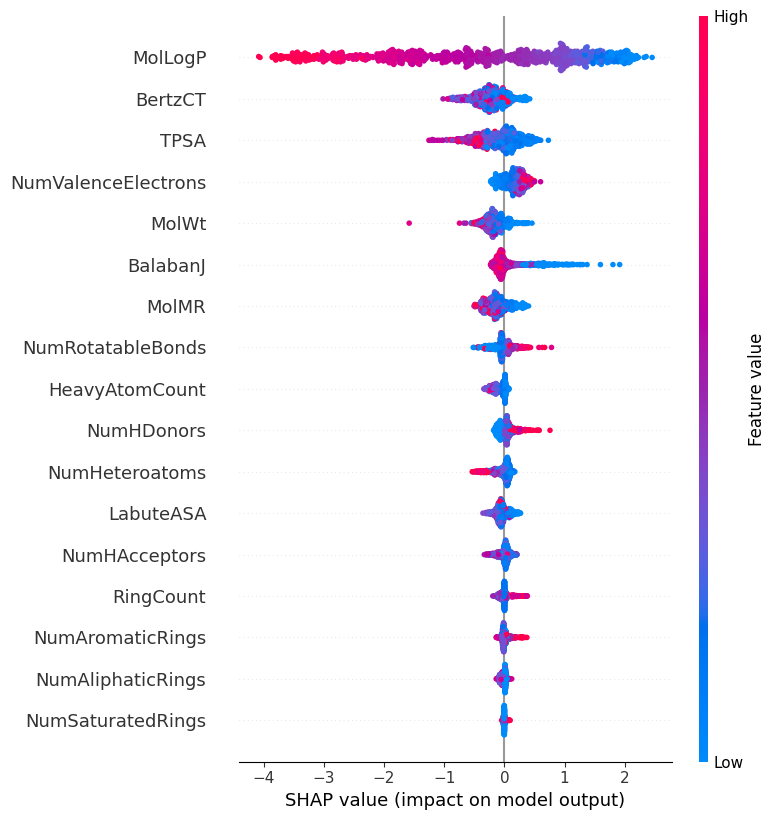

In [38]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=features
)

#2. GNN


In [39]:
!pip install torch torch-geometric

In [197]:
import numpy as np

y = df["Solubility"].values.astype(np.float32)
y_mean, y_std = y.mean(), y.std()
y_norm = (y - y_mean) / y_std

In [198]:
#Re-design the graph
from rdkit import Chem
import torch
from torch_geometric.data import Data
from rdkit.Chem import rdchem

# Allowed atom types
ATOM_LIST = [1, 6, 7, 8, 9, 15, 16, 17, 35, 53]  # H,C,N,O,F,P,S,Cl,Br,I
HYBRID_LIST = [
    rdchem.HybridizationType.SP,
    rdchem.HybridizationType.SP2,
    rdchem.HybridizationType.SP3,
    rdchem.HybridizationType.SP3D,
    rdchem.HybridizationType.SP3D2
]

def one_hot(x, choices):
    return [1 if x == c else 0 for c in choices]

def atom_features(atom):
    z = atom.GetAtomicNum()
    features = []

    # Atom type
    features += one_hot(z, ATOM_LIST)
    features.append(1 if z not in ATOM_LIST else 0)  # other

    # Basic structural info
    features.append(atom.GetDegree())
    features.append(atom.GetFormalCharge())
    features.append(atom.GetTotalNumHs(includeNeighbors=True))
    features.append(1 if atom.GetIsAromatic() else 0)
    features.append(1 if atom.IsInRing() else 0)

    # Hybridization
    features += one_hot(atom.GetHybridization(), HYBRID_LIST)

    return torch.tensor(features, dtype=torch.float)

def bond_features(bond):
    bt = bond.GetBondType()
    features = [
        1 if bt == rdchem.BondType.SINGLE else 0,
        1 if bt == rdchem.BondType.DOUBLE else 0,
        1 if bt == rdchem.BondType.TRIPLE else 0,
        1 if bt == rdchem.BondType.AROMATIC else 0,
        1 if bond.GetIsConjugated() else 0,
        1 if bond.IsInRing() else 0,
    ]
    return torch.tensor(features, dtype=torch.float)

def mol_to_graph(smiles, y_value):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Node features
    x = torch.stack([atom_features(atom) for atom in mol.GetAtoms()])

    # Edge index and edge features
    edge_index = []
    edge_attr = []

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bf = bond_features(bond)

        edge_index += [[i, j], [j, i]]
        edge_attr += [bf, bf]

    if len(edge_index) == 0:
        return None

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.stack(edge_attr)

    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=torch.tensor([y_value], dtype=torch.float)
    )

    return data

In [199]:
train_data = []
val_data = []
test_data = []

for i in train_idx:
    # example inside your dataset build loop
    d = mol_to_graph(df.iloc[i]["SMILES"], y_norm[i])
    if d is not None:
        train_data.append(d)

for i in val_idx:
    d = mol_to_graph(df.iloc[i]["SMILES"], y_norm[i])
    if d is not None:
        val_data.append(d)

for i in test_idx:
    d = mol_to_graph(df.iloc[i]["SMILES"], y_norm[i])
    if d is not None:
        test_data.append(d)

print(len(train_data), len(val_data), len(test_data))

7835 998 998


In [200]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, global_mean_pool

class GINERegressor(nn.Module):
    def __init__(self, node_dim, edge_dim):
        super().__init__()

        mlp1 = nn.Sequential(
            nn.Linear(node_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128)
        )
        self.conv1 = GINEConv(mlp1, edge_dim=edge_dim)

        mlp2 = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128)
        )
        self.conv2 = GINEConv(mlp2, edge_dim=edge_dim)

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = global_mean_pool(x, batch)
        return self.fc(x).squeeze()

In [201]:
print(type(model.conv1))


<class 'torch_geometric.nn.conv.gin_conv.GINEConv'>


In [202]:
from torch_geometric.loader import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128)
test_loader = DataLoader(test_data, batch_size=128)

node_dim = train_data[0].x.shape[1]
edge_dim = train_data[0].edge_attr.shape[1]

model = GINERegressor(node_dim=node_dim, edge_dim=edge_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
loss_fn = nn.MSELoss()

In [203]:
print(train_data[0].x.shape)

torch.Size([23, 21])


In [204]:
def evaluate(loader):
    model.eval()
    ys, preds = [], []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch)

            ys.extend(batch.y.squeeze().cpu().numpy())
            preds.extend(pred.cpu().numpy())

    rmse = np.sqrt(mean_squared_error(ys, preds))
    r2 = r2_score(ys, preds)

    return rmse, r2

In [205]:
print(hasattr(train_data[0], "edge_attr"), train_data[0].edge_attr.shape)

True torch.Size([42, 6])


The graph has 6 bonds

In [206]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

def evaluate(loader):
    model.eval()
    ys, preds = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch)
            ys.extend(batch.y.view(-1).cpu().numpy())
            preds.extend(pred.view(-1).cpu().numpy())
    rmse = np.sqrt(mean_squared_error(ys, preds))
    r2 = r2_score(ys, preds)
    return rmse, r2

for epoch in range(200):
    model.train()
    for batch in train_loader:
        batch = batch.to(device)
        pred = model(batch)
        loss = loss_fn(pred.view(-1), batch.y.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch % 15 == 0:
        train_rmse, train_r2 = evaluate(train_loader)
        val_rmse, val_r2 = evaluate(val_loader)
        print(f"Epoch {epoch:03d} | Train R2 {train_r2:.3f} | Val R2 {val_r2:.3f} | Val RMSE {val_rmse:.3f}")

print("Test:", evaluate(test_loader))

Epoch 000 | Train R2 0.317 | Val R2 0.273 | Val RMSE 0.825
Epoch 015 | Train R2 0.646 | Val R2 0.306 | Val RMSE 0.806
Epoch 030 | Train R2 0.770 | Val R2 0.429 | Val RMSE 0.731
Epoch 045 | Train R2 0.797 | Val R2 0.463 | Val RMSE 0.709
Epoch 060 | Train R2 0.810 | Val R2 0.522 | Val RMSE 0.669
Epoch 075 | Train R2 0.817 | Val R2 0.486 | Val RMSE 0.694
Epoch 090 | Train R2 0.834 | Val R2 0.551 | Val RMSE 0.648
Epoch 105 | Train R2 0.842 | Val R2 0.607 | Val RMSE 0.606
Epoch 120 | Train R2 0.819 | Val R2 0.612 | Val RMSE 0.603
Epoch 135 | Train R2 0.855 | Val R2 0.623 | Val RMSE 0.594
Epoch 150 | Train R2 0.860 | Val R2 0.633 | Val RMSE 0.586
Epoch 165 | Train R2 0.861 | Val R2 0.637 | Val RMSE 0.583
Epoch 180 | Train R2 0.852 | Val R2 0.624 | Val RMSE 0.593
Epoch 195 | Train R2 0.861 | Val R2 0.613 | Val RMSE 0.602
Test: (np.float64(0.5961992619943329), 0.589098449389712)


In [207]:
def evaluate(loader):
    model.eval()
    ys, preds = [], []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch)
            ys.extend(batch.y.squeeze().cpu().numpy())
            preds.extend(pred.cpu().numpy())

    rmse = np.sqrt(mean_squared_error(ys, preds))
    r2 = r2_score(ys, preds)
    return rmse, r2

print("Train:", evaluate(train_loader))
print("Val:", evaluate(val_loader))
print("Test:", evaluate(test_loader))

Train: (np.float64(0.3624347359085105), 0.8670273839670668)
Val: (np.float64(0.5951854156608768), 0.6215370477768607)
Test: (np.float64(0.5961992619943329), 0.589098449389712)


Performed at the same level or slightly worse than XGBOOST
